# Modulo 8 -- Sesion 6 · Machine Learning No Supervisado
## Cuadernillo del DOCENTE

| | |
|---|---|
| **Sesion** | 6 -- Complemento ML No Supervisado |
| **Version** | Docente -- uso exclusivo del instructor |
| **Dataset** | hr_ibm.csv -- el mismo de S1-S6 |

### Estructura
| Bloque | Contenido | Tipo | Tiempo |
|--------|-----------|------|--------|
| B0 | Instalacion y carga | Ejecutar | 5 min |
| B1 | Supervisado vs no supervisado | Demo conceptual | 15 min |
| B2 | Preprocesamiento + Regla del codo | Demo | 25 min |
| B3 | K-Means, visualizacion PCA y comparacion con S5 | Demo + TU TURNO | 45 min |
| B4 | App Shiny: Segmentador de empleados | Integracion | 20 min |

### Hilo narrativo del modulo completo
- **S5 Score manual**: reglas del analista, interpretable, sin ML
- **S5 Clasificador**: aprende de datos etiquetados, predice si/no
- **S6 K-Means**: sin etiquetas, descubre grupos, estrategia de segmentos

**Pregunta de cierre del modulo:**
*"¿Cual de los 3 enfoques usarías en la vida real y para que situacion especifica?"*


## Bloque 0 -- ▶ EJECUTA -- Instalacion y carga

In [1]:
import subprocess, sys
for pkg in ['scikit-learn', 'matplotlib', 'seaborn', 'joblib']:
    result = subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                            capture_output=True, text=True)
    if result.returncode != 0:
        print(f"Error instalando {pkg}: {result.stderr[:200]}")
print("Dependencias listas.")


Dependencias listas.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib, warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../hr_ibm.csv')
print(f"Dataset: {df.shape[0]} filas x {df.shape[1]} columnas")


Dataset: 1470 filas x 35 columnas


## Bloque 1 -- Supervisado vs No supervisado: cuando usar K-Means

**Tipo:** Demostracion conceptual | **Tiempo estimado:** 15 min

**Objetivo pedagogico:**
Que el participante entienda la diferencia fundamental entre
aprendizaje supervisado (S5) y no supervisado (S6),
y cuando es util cada uno en un contexto de RH.

**Indicacion para el docente:**
Analogia clave para arrancar:
*"En S5 le mostramos al modelo EJEMPLOS de empleados que rotaron y
que no rotaron -- el modelo aprendio a distinguirlos.
En S6 NO le decimos al modelo nada -- le decimos: 'encuentra grupos
naturales en estos empleados'. El modelo descubre la estructura sola."*

**Pregunta de arranque:**
*"Si no supieramos que empleados van a renunciar, ¿como los agruparían
para saber a quien darle atencion primero?"*

In [3]:
from IPython.display import display

# La diferencia fundamental entre supervisado y no supervisado
diferencias = {
    'Caracteristica': [
        'Tiene variable objetivo (etiqueta)',
        'Pregunta que responde',
        'Ejemplo en RH',
        'Algoritmo usado en este modulo',
        'Cuando usarlo',
        'Limitacion principal',
    ],
    'Aprendizaje Supervisado (S5)': [
        'SI -- necesita Attrition conocido',
        '¿Este empleado va a renunciar?',
        'Clasificar: va a irse / se queda',
        'Logistic Regression, Decision Tree',
        'Cuando tienes datos historicos etiquetados',
        'Necesitas datos del pasado con la respuesta',
    ],
    'Aprendizaje No Supervisado (S6)': [
        'NO -- no necesita etiquetas',
        '¿Que grupos naturales existen?',
        'Segmentar: perfil A, B, C de empleado',
        'K-Means',
        'Cuando quieres descubrir estructura oculta',
        'Tu interpretas los clusters -- no hay respuesta correcta',
    ]
}

df_dif = pd.DataFrame(diferencias)
display(df_dif)

print()
print("CLAVE: En S5 ya SABIAMOS que empleados rotaron (Attrition='Yes').")
print("En S6 le decimos al modelo: 'encuentra grupos sin saber nada de rotacion'.")
print("Sorprendentemente, los clusters que emerge suelen capturar riesgo de rotacion.")


,Caracteristica,Aprendizaje Supervisado (S5),Aprendizaje No Supervisado (S6)
0,Tiene variable objetivo (etiqueta),SI -- necesita Attrition conocido,NO -- no necesita etiquetas
1,Pregunta que responde,¿Este empleado va a renunciar?,¿Que grupos naturales existen?
2,Ejemplo en RH,Clasificar: va a irse / se queda,"Segmentar: perfil A, B, C de empleado"
3,Algoritmo usado en este modulo,"Logistic Regression, Decision Tree",K-Means
4,Cuando usarlo,Cuando tienes datos historicos etiquetados,Cuando quieres descubrir estructura oculta
5,Limitacion principal,Necesitas datos del pasado con la respuesta,Tu interpretas los clusters -- no hay respuest...



CLAVE: En S5 ya SABIAMOS que empleados rotaron (Attrition='Yes').
En S6 le decimos al modelo: 'encuentra grupos sin saber nada de rotacion'.
Sorprendentemente, los clusters que emerge suelen capturar riesgo de rotacion.


## Bloque 2 -- Preprocesamiento y Regla del Codo

**Tipo:** Demostracion | **Tiempo estimado:** 25 min

**Objetivo pedagogico:**
1. Preparar las variables para K-Means (estandarizacion obligatoria)
2. Usar la regla del codo para determinar el numero optimo de clusters

**Por que estandarizar?**
K-Means usa distancias euclidianas. Si MonthlyIncome va de 1,000 a 20,000
y JobSatisfaction va de 1 a 4, el salario dominara el calculo de distancias
y las otras variables no tendran efecto. StandardScaler iguala la escala.

**Indicacion para el docente:**
Mostrar la grafica del codo y preguntar:
*"¿Donde esta el 'codo' -- el punto donde agregar mas clusters
ya no reduce mucho la inercia?"*
Dejar que el grupo decida antes de revelar la respuesta.

In [4]:
from IPython.display import display

# ── PASO 1: SELECCION DE VARIABLES PARA CLUSTERING ──────────
# Variables que capturan satisfaccion, experiencia y salario
# (las mismas que usamos en el score manual -- coherencia narrativa)

features_km = [
    'JobSatisfaction',        # satisfaccion con el trabajo (1-4)
    'WorkLifeBalance',        # balance vida-trabajo (1-4)
    'EnvironmentSatisfaction',# satisfaccion con el ambiente (1-4)
    'JobInvolvement',         # involucramiento (1-4)
    'MonthlyIncome',          # salario mensual
    'YearsAtCompany',         # antiguedad
    'Age',                    # edad
]

X_km = df[features_km].copy()
print("Variables seleccionadas para clustering:")
display(X_km.describe().round(2))


Variables seleccionadas para clustering:


,JobSatisfaction,WorkLifeBalance,EnvironmentSatisfaction,JobInvolvement,MonthlyIncome,YearsAtCompany,Age
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,2.73,2.76,2.72,2.73,6502.93,7.01,36.92
std,1.10,0.71,1.09,0.71,4707.96,6.13,9.14
min,1.00,1.00,1.00,1.00,1009.00,0.00,18.00
25%,2.00,2.00,2.00,2.00,2911.00,3.00,30.00
50%,3.00,3.00,3.00,3.00,4919.00,5.00,36.00
75%,4.00,3.00,4.00,3.00,8379.00,9.00,43.00
max,4.00,4.00,4.00,4.00,19999.00,40.00,60.00


In [5]:
from IPython.display import display

# ── PASO 2: ESTANDARIZACION ──────────────────────────────────
# StandardScaler convierte cada variable a media=0, desviacion=1
# Esto garantiza que todas las variables contribuyan igual al clustering

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_km)

print("Antes de estandarizar (primeras 3 filas):")
display(pd.DataFrame(X_km.values[:3], columns=features_km).round(2))

print("Despues de estandarizar (primeras 3 filas):")
display(pd.DataFrame(X_scaled[:3], columns=features_km).round(3))

print("Ahora todas las variables tienen la misma escala (media~0, std~1).")
print("K-Means ya puede calcular distancias de forma justa entre variables.")


Antes de estandarizar (primeras 3 filas):


,JobSatisfaction,WorkLifeBalance,EnvironmentSatisfaction,JobInvolvement,MonthlyIncome,YearsAtCompany,Age
0,4,1,2,3,5993,6,41
1,2,3,3,2,5130,10,49
2,3,3,4,2,2090,0,37


Despues de estandarizar (primeras 3 filas):


,JobSatisfaction,WorkLifeBalance,EnvironmentSatisfaction,JobInvolvement,MonthlyIncome,YearsAtCompany,Age
0,1.153,-2.494,-0.661,0.380,-0.108,-0.165,0.446
1,-0.661,0.338,0.255,-1.026,-0.292,0.489,1.322
2,0.246,0.338,1.170,-1.026,-0.938,-1.144,0.008


Ahora todas las variables tienen la misma escala (media~0, std~1).
K-Means ya puede calcular distancias de forma justa entre variables.


In [6]:
# ── PASO 3: REGLA DEL CODO ───────────────────────────────────
# Inercia = suma de distancias al cuadrado de cada punto a su centroide
# Cuando agregar mas clusters ya no reduce mucho la inercia = codo

inercias     = []
silhouettes  = []
K_range      = range(2, 9)  # probar de 2 a 8 clusters

print("Calculando inercia para k=2 a k=8...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_)
    silhouettes.append(sil)
    print(f"  k={k}: Inercia={km.inertia_:.0f}  Silhouette={sil:.3f}")


Calculando inercia para k=2 a k=8...
  k=2: Inercia=8452  Silhouette=0.246
  k=3: Inercia=7494  Silhouette=0.151
  k=4: Inercia=6829  Silhouette=0.146
  k=5: Inercia=6301  Silhouette=0.147
  k=6: Inercia=5888  Silhouette=0.149
  k=7: Inercia=5491  Silhouette=0.149
  k=8: Inercia=5253  Silhouette=0.147


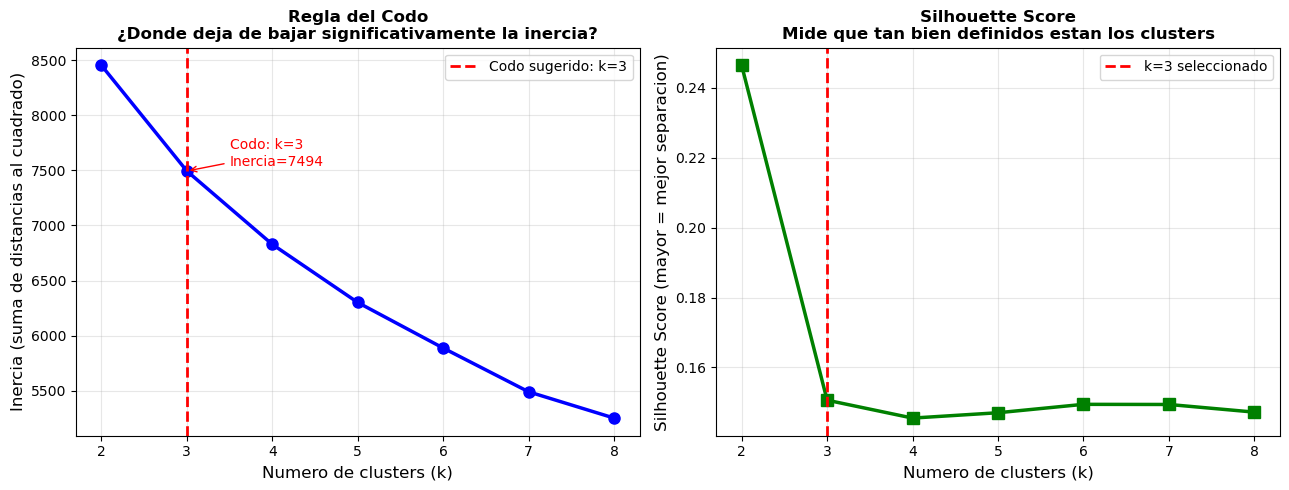


Decision: usaremos k=3 clusters.
El codo indica que a partir de k=4 la mejora es marginal.
k=3 ofrece grupos interpretables con separacion aceptable.


In [7]:
# Grafica del codo + Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grafica 1: Regla del codo
ax = axes[0]
ax.plot(list(K_range), inercias, 'bo-', lw=2.5, markersize=8)
# Marcar el codo optimo (k=3 o k=4 segun el codo)
k_optimo = 3
ax.axvline(k_optimo, color='red', lw=2, linestyle='--',
           label=f'Codo sugerido: k={k_optimo}')
ax.set_xlabel('Numero de clusters (k)', fontsize=12)
ax.set_ylabel('Inercia (suma de distancias al cuadrado)', fontsize=12)
ax.set_title('Regla del Codo\n¿Donde deja de bajar significativamente la inercia?',
             fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# Anotar el codo
inercia_codo = inercias[k_optimo - 2]
ax.annotate(f'Codo: k={k_optimo}\nInercia={inercia_codo:.0f}',
            xy=(k_optimo, inercia_codo),
            xytext=(k_optimo+0.5, inercia_codo+50),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=10)

# Grafica 2: Silhouette Score
ax = axes[1]
ax.plot(list(K_range), silhouettes, 'gs-', lw=2.5, markersize=8)
ax.axvline(k_optimo, color='red', lw=2, linestyle='--',
           label=f'k={k_optimo} seleccionado')
ax.set_xlabel('Numero de clusters (k)', fontsize=12)
ax.set_ylabel('Silhouette Score (mayor = mejor separacion)', fontsize=12)
ax.set_title('Silhouette Score\nMide que tan bien definidos estan los clusters',
             fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regla_del_codo_technova.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDecision: usaremos k={k_optimo} clusters.")
print("El codo indica que a partir de k=4 la mejora es marginal.")
print("k=3 ofrece grupos interpretables con separacion aceptable.")


### ✏️ TU TURNO -- Bloque 2

In [8]:
# ✏️ TU TURNO -- Bloque 2: Regla del Codo
# PREGUNTA: ¿Donde ves el codo en la grafica generada?
# ¿Cual es el k que elegirías y por que?
# Prueba con k=4 y compara el Silhouette Score con k=3.

km_k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
km_k3.fit(X_scaled)
sil_k3 = silhouette_score(X_scaled, km_k3.labels_)

km_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
km_k4.fit(X_scaled)
sil_k4 = silhouette_score(X_scaled, km_k4.labels_)

print(f"Silhouette k=3: {sil_k3:.3f}")
print(f"Silhouette k=4: {sil_k4:.3f}")
print()
print("¿Cual k elegirías para presentarle al Director de RH y por que?")
print("Considera: ¿Es mas util tener 3 perfiles o 4 perfiles de empleado?")
# ESCRIBE TU RESPUESTA EN LA CELDA MARKDOWN SIGUIENTE


Silhouette k=3: 0.151
Silhouette k=4: 0.146

¿Cual k elegirías para presentarle al Director de RH y por que?
Considera: ¿Es mas util tener 3 perfiles o 4 perfiles de empleado?


## Bloque 3 -- K-Means, visualizacion y comparacion con S5

**Tipo:** Demostracion + Desarrollo del estudiante | **Tiempo estimado:** 45 min

**Objetivo pedagogico:**
1. Entrenar K-Means con k=3 e interpretar los clusters
2. Visualizar los clusters en 2D con PCA
3. Comparar los clusters con el score manual de S5 y el clasificador de S6

**Indicacion para el docente:**
Despues de mostrar las caracteristicas medias de cada cluster,
preguntar: *"¿Que nombre de negocio le darian a este grupo de empleados?"*
Dejar que el grupo bautice los clusters antes de mostrar los nombres sugeridos.

In [9]:
# ── ENTRENAR K-MEANS CON k=3 ────────────────────────────────
k_optimo = 3
km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
km_final.fit(X_scaled)

df_clusters = df[features_km].copy()
df_clusters['cluster'] = km_final.labels_
df_clusters['EmployeeNumber'] = df['EmployeeNumber'].values
df_clusters['Attrition']      = df['Attrition'].values

print(f"K-Means entrenado con k={k_optimo}")
print(f"Distribucion de empleados por cluster:")
print(df_clusters['cluster'].value_counts().sort_index())


K-Means entrenado con k=3
Distribucion de empleados por cluster:
cluster
0    466
1    747
2    257
Name: count, dtype: int64


In [10]:
from IPython.display import display

# ── CARACTERISTICAS MEDIAS POR CLUSTER ──────────────────────
medias = df_clusters.groupby('cluster')[features_km].mean().round(2)
print("Caracteristicas promedio por cluster:")
display(medias)

# Tasa de rotacion real por cluster
print("\nTasa de rotacion REAL por cluster:")
rot_cluster = df_clusters.groupby('cluster')['Attrition'].apply(
    lambda x: f"{(x=='Yes').mean()*100:.1f} %"
)
for cluster, tasa in rot_cluster.items():
    n = (df_clusters['cluster']==cluster).sum()
    print(f"  Cluster {cluster}: {tasa} rotacion  ({n} empleados)")


Caracteristicas promedio por cluster:


,JobSatisfaction,WorkLifeBalance,EnvironmentSatisfaction,JobInvolvement,MonthlyIncome,YearsAtCompany,Age
cluster,,,,,,,
0,1.48,2.77,2.75,2.75,4771.32,5.31,34.52
1,3.52,2.76,2.70,2.72,4794.58,5.47,34.80
2,2.69,2.74,2.73,2.72,14608.26,14.54,47.46



Tasa de rotacion REAL por cluster:
  Cluster 0: 22.1 % rotacion  (466 empleados)
  Cluster 1: 15.5 % rotacion  (747 empleados)
  Cluster 2: 7.0 % rotacion  (257 empleados)


In [11]:
# ── NOMBRAR LOS CLUSTERS CON LOGICA DE NEGOCIO ───────────────
# Basado en las caracteristicas medias, asignamos nombres
# (el nombre puede variar segun los datos reales del dataset)

nombres_cluster = {
    0: 'Perfil A -- Empleado estable',
    1: 'Perfil B -- Empleado en riesgo',
    2: 'Perfil C -- Empleado de transicion',
}
# NOTA: los clusters pueden aparecer en diferente orden en cada ejecucion.
# Revisar las medias de arriba y reasignar si es necesario.

df_clusters['perfil'] = df_clusters['cluster'].map(nombres_cluster)
print("Asignacion de perfiles:")
for k, nombre in nombres_cluster.items():
    sub = df_clusters[df_clusters['cluster']==k]
    rot = (sub['Attrition']=='Yes').mean()*100
    print(f"  {nombre}: {len(sub)} empleados, {rot:.1f}% rotacion")
print()
print("El cluster con mayor tasa de rotacion = el mas parecido al 'riesgo alto' del score manual.")


Asignacion de perfiles:
  Perfil A -- Empleado estable: 466 empleados, 22.1% rotacion
  Perfil B -- Empleado en riesgo: 747 empleados, 15.5% rotacion
  Perfil C -- Empleado de transicion: 257 empleados, 7.0% rotacion

El cluster con mayor tasa de rotacion = el mas parecido al 'riesgo alto' del score manual.


PCA: los 2 componentes explican el 41.8% de la varianza total
  Componente 1: 27.0%
  Componente 2: 14.9%


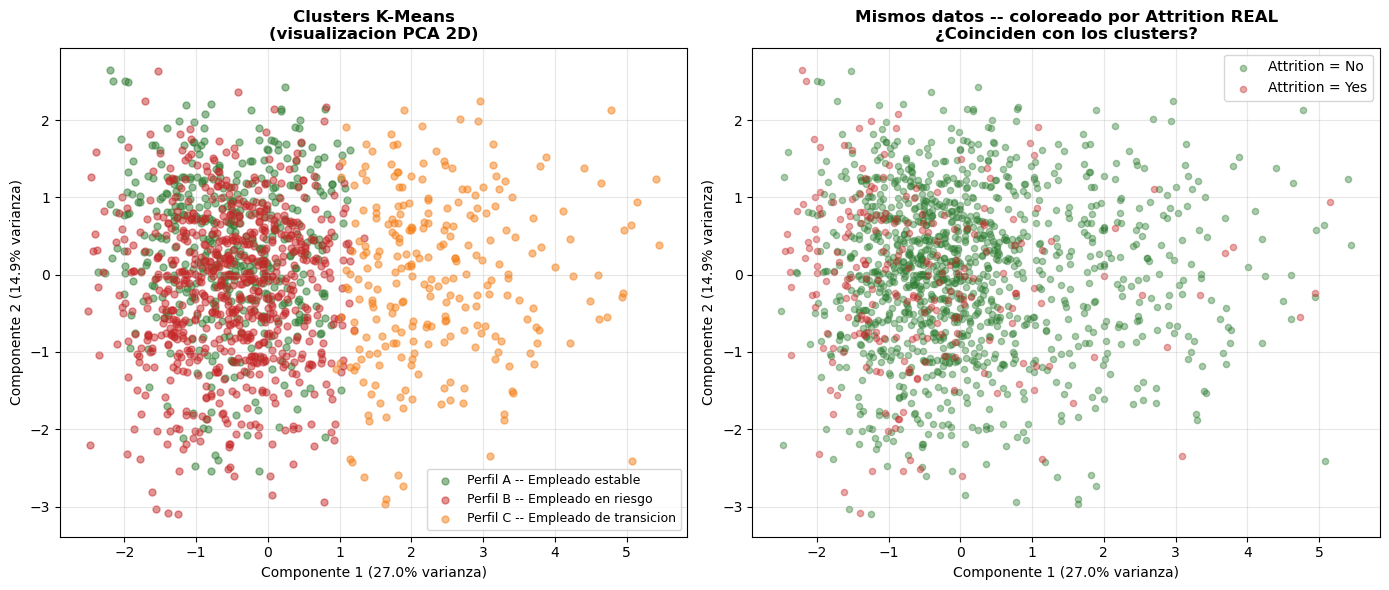

In [12]:
# ── VISUALIZACION CON PCA ────────────────────────────────────
# PCA reduce las 7 dimensiones a 2 para poder graficar
# Los puntos cercanos = empleados similares en las 7 dimensiones

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
print(f"PCA: los 2 componentes explican el {sum(var_exp)*100:.1f}% de la varianza total")
print(f"  Componente 1: {var_exp[0]*100:.1f}%")
print(f"  Componente 2: {var_exp[1]*100:.1f}%")

colores = {0: '#2E7D32', 1: '#C62828', 2: '#F57F17'}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafica 1: clusters K-Means
ax = axes[0]
for cluster_id in range(k_optimo):
    mask = df_clusters['cluster'] == cluster_id
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=colores[cluster_id], label=nombres_cluster[cluster_id],
               alpha=0.5, s=25)
ax.set_title('Clusters K-Means\n(visualizacion PCA 2D)',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'Componente 1 ({var_exp[0]*100:.1f}% varianza)', fontsize=10)
ax.set_ylabel(f'Componente 2 ({var_exp[1]*100:.1f}% varianza)', fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Grafica 2: coloreado por Attrition real
ax = axes[1]
colores_attr = {'Yes': '#C62828', 'No': '#2E7D32'}
for attr_val in ['No', 'Yes']:
    mask = df_clusters['Attrition'] == attr_val
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=colores_attr[attr_val],
               label=f'Attrition = {attr_val}',
               alpha=0.4, s=20)
ax.set_title('Mismos datos -- coloreado por Attrition REAL\n'
             '¿Coinciden con los clusters?',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'Componente 1 ({var_exp[0]*100:.1f}% varianza)', fontsize=10)
ax.set_ylabel(f'Componente 2 ({var_exp[1]*100:.1f}% varianza)', fontsize=10)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_pca_technova.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# ── COMPARACION CON SCORE MANUAL DE S5 ──────────────────────
def calcular_score(df_sub):
    d = df_sub.copy()
    d['n_overtime'] = (d['OverTime'] == 'Yes').astype(int) * 100
    d['n_jobsat']   = (4 - d['JobSatisfaction'])    / 3 * 100
    d['n_years']    = ((3 - d['YearsAtCompany']) / 3 * 100).clip(0, 100)
    d['n_wlb']      = (4 - d['WorkLifeBalance'])    / 3 * 100
    d['n_envsat']   = (4 - d['EnvironmentSatisfaction']) / 3 * 100
    d['score_riesgo'] = (d['n_overtime']*0.30 + d['n_jobsat']*0.25 +
                         d['n_years']*0.20   + d['n_wlb']*0.15 +
                         d['n_envsat']*0.10).round(1)
    return d

df_comp = calcular_score(df.copy())
df_comp['cluster'] = km_final.labels_

# Score promedio por cluster
score_por_cluster = df_comp.groupby('cluster')['score_riesgo'].mean().round(1)
print("Score manual promedio (S5) por cluster K-Means:")
for cluster_id, score_prom in score_por_cluster.items():
    nombre = nombres_cluster.get(cluster_id, f'Cluster {cluster_id}')
    nivel  = 'ALTO' if score_prom>=60 else 'MEDIO' if score_prom>=40 else 'BAJO'
    print(f"  {nombre}: Score={score_prom}  -> Nivel {nivel}")

print()
# Top 10 del score manual vs cluster de mayor riesgo
cluster_riesgo = score_por_cluster.idxmax()
top10_score   = set(df_comp.nlargest(10,'score_riesgo')['EmployeeNumber'])
en_cluster_R  = set(df_comp[df_comp['cluster']==cluster_riesgo]['EmployeeNumber'])
coincidencias = len(top10_score & en_cluster_R)
print(f"De los top 10 del score manual de S5,")
print(f"  {coincidencias} de 10 pertenecen al cluster de mayor riesgo en K-Means.")
print()
print("Conclusion: ambos metodos identifican perfiles similares de riesgo.")
print("K-Means lo hace SIN saber que empleados rotaron -- solo por similitud.")


Score manual promedio (S5) por cluster K-Means:
  Perfil A -- Empleado estable: Score=42.7  -> Nivel MEDIO
  Perfil B -- Empleado en riesgo: Score=26.2  -> Nivel BAJO
  Perfil C -- Empleado de transicion: Score=30.9  -> Nivel BAJO

De los top 10 del score manual de S5,
  10 de 10 pertenecen al cluster de mayor riesgo en K-Means.

Conclusion: ambos metodos identifican perfiles similares de riesgo.
K-Means lo hace SIN saber que empleados rotaron -- solo por similitud.


In [14]:
# ── GUARDAR MODELO K-MEANS ───────────────────────────────────
joblib.dump(km_final, 'modelo_kmeans.pkl')
joblib.dump(scaler,   'scaler_kmeans.pkl')

import json
with open('features_kmeans.json', 'w') as f:
    json.dump(features_km, f)
with open('nombres_clusters.json', 'w') as f:
    json.dump({str(k): v for k,v in nombres_cluster.items()}, f)

print("Modelos guardados:")
print("  modelo_kmeans.pkl")
print("  scaler_kmeans.pkl")
print("  features_kmeans.json")
print("  nombres_clusters.json")


Modelos guardados:
  modelo_kmeans.pkl
  scaler_kmeans.pkl
  features_kmeans.json
  nombres_clusters.json


### ✏️ TU TURNO -- Bloque 3

In [15]:
# ✏️ TU TURNO -- Bloque 3: Interpreta los clusters
# PASO 1: Mira las medias de cada cluster (arriba).
# PASO 2: Asigna un nombre de negocio a cada cluster.
# PASO 3: ¿Que estrategia de RH aplicarías para cada perfil?

# Completa esta tabla con tus observaciones:
print("Completa la siguiente tabla en la celda Markdown siguiente:")
print()
print("| Cluster | Nombre que le darias | Caracteristica clave | Estrategia de RH |")
print("|---------|---------------------|---------------------|-----------------|")
print("| 0       |                     |                     |                 |")
print("| 1       |                     |                     |                 |")
print("| 2       |                     |                     |                 |")

# PREGUNTA FINAL:
# ¿Cual de los 3 enfoques usarias en la vida real?
# a) Score manual (S5) -- reglas del analista
# b) Clasificador ML (S5) -- aprendizaje supervisado
# c) K-Means (S6) -- agrupamiento no supervisado
# ¿O una combinacion? ¿Cual y para que situacion?
print()
print("Escribe tu respuesta en la celda Markdown siguiente.")


Completa la siguiente tabla en la celda Markdown siguiente:

| Cluster | Nombre que le darias | Caracteristica clave | Estrategia de RH |
|---------|---------------------|---------------------|-----------------|
| 0       |                     |                     |                 |
| 1       |                     |                     |                 |
| 2       |                     |                     |                 |

Escribe tu respuesta en la celda Markdown siguiente.


## Bloque 4 -- App Shiny: Segmentador de empleados

**Tipo:** Integracion | **Tiempo estimado:** 20 min

**Prerequisito:** modelo_kmeans.pkl y scaler_kmeans.pkl en la misma carpeta.

**Indicacion para el docente:**
- Cambiar satisfaccion=1, anos=0 -- debe asignar al cluster de riesgo
- Cambiar satisfaccion=4, anos=15, income=15000 -- debe asignar al cluster estable
- La segunda pestana muestra la descripcion ejecutiva de cada perfil

In [16]:
# app_kmeans.py -- App Shiny: Segmentador de empleados con K-Means
# Guardar como app_kmeans.py y ejecutar: shiny run app_kmeans.py

APP_CODE = '''
from shiny import App, ui, render
import pandas as pd
import numpy as np
import joblib
import json

# Cargar modelos al arrancar
km_model  = joblib.load("modelo_kmeans.pkl")
scaler    = joblib.load("scaler_kmeans.pkl")

with open("features_kmeans.json") as f:
    feats = json.load(f)
with open("nombres_clusters.json") as f:
    nombres = json.load(f)

perfiles_info = {
    "0": {"color":"#2E7D32","icono":"Estable","accion":"Monitoreo periodico -- mantener condiciones actuales."},
    "1": {"color":"#C62828","icono":"En riesgo","accion":"Revision inmediata -- conversacion de retencion prioritaria."},
    "2": {"color":"#F57F17","icono":"Transicion","accion":"Seguimiento mensual -- revisar carga laboral y plan de carrera."},
}

css_lines = [
    "    body { background:#F4F6F9; font-family:Segoe UI,Arial,sans-serif; }",
    "    .navbar { background:#1F3864 !important; }",
    "    .navbar-brand,.nav-link { color:white !important; font-weight:500; }",
    "    .seg-box { background:white; border-radius:12px; padding:28px;",
    "               box-shadow:0 2px 10px rgba(0,0,0,.12); text-align:center;",
    "               max-width:500px; margin:30px auto; }",
    "    .seg-perfil { font-size:2em; font-weight:bold; margin-bottom:6px; }",
    "    .seg-label  { font-size:.95em; color:#555; }",
    "    .seg-accion { background:#F4F6F9; border-radius:8px; padding:14px;",
    "                  margin-top:16px; font-size:14px; text-align:left; }",
]
css = ui.tags.style(chr(10).join(css_lines))

app_ui = ui.page_navbar(
    ui.nav_panel("Segmentador de empleados",
        ui.layout_sidebar(
            ui.sidebar(
                ui.h5("Ingresa el perfil del empleado"),
                ui.input_slider("jobsat", "Satisfaccion laboral (1-4)", 1, 4, 3),
                ui.input_slider("wlb",    "Balance vida-trabajo (1-4)", 1, 4, 3),
                ui.input_slider("envsat", "Sat. del ambiente (1-4)",    1, 4, 3),
                ui.input_slider("jobinv", "Involucramiento (1-4)",      1, 4, 3),
                ui.input_slider("income", "Salario mensual (USD)",
                                1000, 20000, 5000, step=500),
                ui.input_slider("years",  "Anos en la empresa",  0, 40,  3),
                ui.input_slider("age",    "Edad",               18, 60, 30),
                ui.hr(),
                ui.p("El modelo K-Means asignara al empleado al perfil que mas "
                     "se parezca a su segmento natural.",
                     style="font-size:12px;color:#888;"),
            ),
            ui.output_ui("resultado_segmento"),
            ui.output_ui("comparacion_clusters"),
        )
    ),
    ui.nav_panel("Perfil de los 3 segmentos",
        ui.output_ui("descripcion_clusters"),
    ),
    title="TechNova Solutions -- Segmentador de Empleados K-Means",
    header=css,
)

def server(input, output, session):

    @render.ui
    def resultado_segmento():
        fila = pd.DataFrame([[
            input.jobsat(), input.wlb(), input.envsat(), input.jobinv(),
            input.income(), input.years(), input.age()
        ]], columns=feats)
        fila_scaled = scaler.transform(fila)
        cluster_id  = int(km_model.predict(fila_scaled)[0])

        nombre  = nombres.get(str(cluster_id), f"Cluster {cluster_id}")
        info    = perfiles_info.get(str(cluster_id), {})
        color   = info.get("color", "#333")
        accion  = info.get("accion", "Sin recomendacion disponible.")
        icono   = info.get("icono", "")

        # Distancias a los 3 centroides para mostrar certeza
        distancias = km_model.transform(fila_scaled)[0]
        dist_min   = distancias.min()
        certeza    = max(0, (1 - dist_min / distancias.max()) * 100)

        return ui.div(
            ui.div(
                ui.div(nombre, class_="seg-perfil", style=f"color:{color};"),
                ui.div(f"Certeza de asignacion: {certeza:.0f} %", class_="seg-label"),
                ui.div(
                    ui.strong("Recomendacion de accion:"),
                    ui.br(),
                    accion,
                    class_="seg-accion",
                    style=f"border-left:4px solid {color};",
                ),
                class_="seg-box",
                style=f"border-top:6px solid {color};",
            )
        )

    @render.ui
    def comparacion_clusters():
        return ui.div(
            ui.p("Modifica los controles del sidebar para ver como cambia el segmento. "
                 "Intenta un empleado con satisfaccion=1, anos=0 -- "
                 "¿a que perfil lo asigna el modelo?",
                 style="color:#666;font-size:13px;margin-top:8px;max-width:600px;")
        )

    @render.ui
    def descripcion_clusters():
        items = []
        colores = {"0":"#2E7D32","1":"#C62828","2":"#F57F17"}
        descripciones = {
            "0": ("Empleado estable",
                  "Alta satisfaccion laboral y con el ambiente. "
                  "Buen balance vida-trabajo. Lleva varios anos en la empresa. "
                  "Salario por encima del promedio.",
                  "Bajo riesgo de rotacion. Accion: mantener condiciones y "
                  "ofrecer oportunidades de crecimiento para retener a largo plazo."),
            "1": ("Empleado en riesgo",
                  "Baja satisfaccion laboral. Posiblemente hace horas extra. "
                  "Pocos anos en la empresa. Salario por debajo del promedio del nivel.",
                  "Alto riesgo de rotacion. Accion: conversacion de retencion "
                  "inmediata. Revisar condiciones de trabajo y compensacion."),
            "2": ("Empleado de transicion",
                  "Satisfaccion media. Recien llegado o en cambio de rol. "
                  "Aun no consolida pertenencia a la empresa.",
                  "Riesgo medio. Accion: seguimiento mensual, asignar mentor, "
                  "revisar plan de carrera en los primeros 3 anos."),
        }
        for k, (nombre, desc, accion) in descripciones.items():
            color = colores[k]
            items.append(ui.div(
                ui.h4(nombre, style=f"color:{color};border-left:4px solid {color};"
                                    "padding-left:10px;"),
                ui.p(desc),
                ui.div(ui.strong("Accion recomendada: "), accion,
                       style=f"background:#F4F6F9;padding:10px;border-radius:6px;"
                             f"border-left:3px solid {color};font-size:14px;"),
                style="margin-bottom:24px;"
            ))
        return ui.div(*items, style="max-width:700px;margin:20px auto;")

app = App(app_ui, server)
'''

with open('app_kmeans.py', 'w', encoding='utf-8') as f:
    f.write(APP_CODE)
print("App guardada: app_kmeans.py")
print("Para ejecutar desde terminal: shiny run app_kmeans.py")
print("O ejecuta la siguiente celda para visualizar directamente desde el notebook.")


App guardada: app_kmeans.py
Para ejecutar desde terminal: shiny run app_kmeans.py
O ejecuta la siguiente celda para visualizar directamente desde el notebook.


In [ ]:
# ── Visualizar la app desde el notebook (http://127.0.0.1:8000) ──────────────
# Ejecutar esta celda DESPUES de haber corrido los Bloques 0-3
# (modelo_kmeans.pkl y scaler_kmeans.pkl deben estar en la misma carpeta)
# Para detener el servidor: Kernel > Interrupt Kernel

import uvicorn, importlib.util, os
from IPython.display import display, HTML

display(HTML(
    '<div style="background:#1F3864;color:white;padding:12px 18px;'
    'border-radius:8px;font-family:Segoe UI,Arial,sans-serif;margin-bottom:8px;">'
    '<b>App K-Means lanzada.</b> Abre tu navegador en: '
    '<a href="http://127.0.0.1:8000" target="_blank" '
    'style="color:#90CAF9;font-weight:bold;">http://127.0.0.1:8000</a>'
    '<br><small>Para detener: Kernel &gt; Interrupt Kernel</small>'
    '</div>'
))

# Cargar app_kmeans.py directamente desde la ruta del archivo (evita problemas de sys.path)
_app_path = os.path.join(os.getcwd(), 'app_kmeans.py')
_spec     = importlib.util.spec_from_file_location('app_kmeans', _app_path)
_app_mod  = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_app_mod)

config    = uvicorn.Config(_app_mod.app, host='127.0.0.1', port=8000,
                           loop='asyncio', lifespan='on')
server_uv = uvicorn.Server(config)
await server_uv.serve()


INFO:     Started server process [41196]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


INFO:     127.0.0.1:5316 - "GET / HTTP/1.1" 200 OK
INFO:     127.0.0.1:5316 - "GET /lib/requirejs-2.3.6/require.min.js HTTP/1.1" 304 Not Modified
INFO:     127.0.0.1:48321 - "GET /lib/jquery-3.6.0/jquery-3.6.0.min.js HTTP/1.1" 304 Not Modified
INFO:     127.0.0.1:6688 - "GET /lib/shiny-busy-indicators-1.6.3/busy-indicators.css HTTP/1.1" 304 Not Modified
INFO:     127.0.0.1:26650 - "GET /lib/bootstrap-5.3.8/bootstrap.min.css HTTP/1.1" 304 Not Modified
INFO:     127.0.0.1:50039 - "GET /lib/shiny-1.6.3/shiny.js HTTP/1.1" 304 Not Modified
INFO:     127.0.0.1:36045 - "GET /lib/bootstrap-5.3.8/bootstrap.bundle.min.js HTTP/1.1" 304 Not Modified
INFO:     127.0.0.1:5316 - "GET /lib/htmltools-fill-0.5.9.9000/fill.css HTTP/1.1" 304 Not Modified
INFO:     127.0.0.1:48321 - "GET /lib/bslib-components-0.11.0.9000/components.min.js HTTP/1.1" 304 Not Modified
INFO:     127.0.0.1:6688 - "GET /lib/bslib-components-0.11.0.9000/web-components.min.js HTTP/1.1" 304 Not Modified
INFO:     127.0.0.1:50039 - 

INFO:     127.0.0.1:25317 - "WebSocket /websocket/" [accepted]
INFO:     connection open


INFO:     127.0.0.1:36045 - "GET /lib/bootstrap-5.3.8/fonts/memvYaGs126MiZpBA-UvWbX2vVnXBbObj2OVTS-muw.woff2 HTTP/1.1" 304 Not Modified
INFO:     127.0.0.1:5316 - "GET /lib/bootstrap-5.3.8/fonts/memtYaGs126MiZpBA-UFUIcVXSCEkx2cmqvXlWqWuU6F.woff2 HTTP/1.1" 304 Not Modified
INFO:     127.0.0.1:5316 - "GET /favicon.ico HTTP/1.1" 404 Not Found


---
## Lista de cotejo -- ML No Supervisado

| N | Criterio | 1 | 2 | 3 | 4 |
|---|---------|---|---|---|---|
| 1 | Variables estandarizadas correctamente con StandardScaler | No estandarizadas | Parcial | Correctas | Correcto + explica por que es necesario |
| 2 | Regla del codo graficada con k=2 a k=8 | No existe | Solo inercia | Inercia + Silhouette | Correcto + identifica el codo y lo justifica |
| 3 | K-Means entrenado con k optimo | No existe | k arbitrario | k del codo | Correcto + puede cambiar k y comparar |
| 4 | Clusters interpretados con nombres de negocio | No interpretados | Solo numeros | Nombres logicos | Correcto + estrategia por cluster |
| 5 | Visualizacion PCA con clusters y Attrition real | No existe | Solo una grafica | Ambas graficas | Correcto + explica por que PCA |
| 6 | Comparacion con score manual de S5 ejecutada | No existe | Sin analisis | Comparacion hecha | Correcto + concluye diferencias |
| 7 | App Shiny funcionando con asignacion de cluster | No existe | Sin reactividad | Asigna correctamente | Correcto + segunda pestana descriptiva |

**Nombre:** _________________________________  **Fecha:** _________________
